In [68]:
!pip install geopy

In [69]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic

In [70]:
df = pd.read_csv("credit_card_frauds.csv")
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [71]:
df.shape

(339607, 15)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [73]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


In [74]:
df['is_fraud'].value_counts()

,count
is_fraud,
0,337825
1,1782


In [75]:
1782/df.shape[0]*100

0.5247241664629999

Heavy imbalance with only .52% fraud

In [76]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

In [77]:
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud,hour,day,month
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0,0,1,1
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0,0,1,1
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0,0,1,1
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0,0,1,1
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0,0,1,1


In [78]:
df.drop('trans_date_trans_time', axis = 1, inplace=True)

In [79]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = 2026 - df['dob'].dt.year

In [80]:
def compute_distance(row):
    return geodesic(
        (row['lat'], row['long']),
        (row['merch_lat'], row['merch_long'])
    ).km

df['distance_km'] = df.apply(compute_distance, axis=1)

In [81]:
df.drop(['dob', 'trans_num'], axis =1)

,merchant,category,amt,city,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,day,month,age,distance_km
0,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,0,1,1,48,30.216618
1,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,0,1,1,64,108.102912
2,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,41.657520,-122.230347,0,0,1,1,81,25.120545
3,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,32.863258,-106.520205,0,0,1,1,59,66.155859
4,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",43.753735,-111.454923,0,0,1,1,59,88.802805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339602,Schmidt-Larkin,home,12.68,Wales,AK,64.7556,-165.6723,145,"Administrator, education",65.623593,-165.186033,0,23,31,12,87,99.420757
339603,"Pouros, Walker and Spence",kids_pets,13.02,Greenview,CA,41.5403,-122.9366,308,Call centre manager,41.973127,-123.553032,0,23,31,12,68,70.279450
339604,Reilly and Sons,health_fitness,43.77,Luray,MO,40.4931,-91.8912,519,Town planner,39.946837,-91.333331,0,23,31,12,60,77.032467
339605,Rau-Robel,kids_pets,86.88,Burbank,WA,46.1966,-118.9017,3684,Musician,46.658340,-119.715054,0,23,31,12,45,80.887812


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 19 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   merchant     339607 non-null  object        
 1   category     339607 non-null  object        
 2   amt          339607 non-null  float64       
 3   city         339607 non-null  object        
 4   state        339607 non-null  object        
 5   lat          339607 non-null  float64       
 6   long         339607 non-null  float64       
 7   city_pop     339607 non-null  int64         
 8   job          339607 non-null  object        
 9   dob          339607 non-null  datetime64[ns]
 10  trans_num    339607 non-null  object        
 11  merch_lat    339607 non-null  float64       
 12  merch_long   339607 non-null  float64       
 13  is_fraud     339607 non-null  int64         
 14  hour         339607 non-null  int32         
 15  day          339607 non-null  int3

In [83]:
df.describe()

,amt,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud,hour,day,month,age,distance_km
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607,339607.000000,339607.000000,339607.000000,339607.000000,339607.000000,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,1972-04-03 19:05:18.385663432,39.718853,-110.622383,0.005247,12.814480,15.850648,7.157897,54.267344,75.584370
min,1.000000,20.027100,-165.672300,4.600000e+01,1927-09-09 00:00:00,19.027422,-166.671575,0.000000,0.000000,1.000000,1.000000,25.000000,0.205421
25%,9.600000,36.715400,-120.093600,4.710000e+02,1961-10-24 00:00:00,36.817194,-119.823755,0.000000,7.000000,8.000000,4.000000,41.000000,54.765937
50%,46.460000,39.617100,-111.098500,1.645000e+03,1974-03-10 00:00:00,39.586209,-111.036443,0.000000,14.000000,16.000000,7.000000,52.000000,77.648524
75%,83.350000,41.710000,-100.621500,3.543900e+04,1985-08-21 00:00:00,42.193072,-100.353096,0.000000,19.000000,24.000000,10.000000,65.000000,97.913962
max,28948.900000,66.693300,-89.628700,2.383912e+06,2001-07-26 00:00:00,67.510267,-88.629203,1.000000,23.000000,31.000000,12.000000,99.000000,151.868200
std,161.675242,5.094961,12.651370,2.930299e+05,NaN,5.130894,12.663998,0.072248,6.812057,8.873150,3.423984,16.986138,29.033279


In [84]:
(
df[df['is_fraud'] == 1]
  .groupby(['merchant', 'category'])
  .size()
  .reset_index(name = "fraud_count")
  .sort_values("fraud_count", ascending=False)
)

,merchant,category,fraud_count
228,Kiehn-Emmerich,grocery_pos,19
393,"Romaguera, Cruickshank and Greenholt",shopping_net,18
223,Kerluke-Abshire,shopping_net,17
263,Kunze Inc,grocery_pos,16
454,Strosin-Cruickshank,grocery_pos,14
...,...,...,...
490,Weimann-Lockman,kids_pets,1
492,"Welch, Rath and Koepp",entertainment,1
493,White and Sons,home,1
4,"Adams, Kovacek and Kuhlman",grocery_net,1


In [85]:
fraud_merchants = (
df[df['is_fraud'] == 1]
  .groupby(['merchant'])
  .size()
  .reset_index(name = "fraud_count")
  .sort_values("fraud_count", ascending=False)
)

print(fraud_merchants)


                                 merchant  fraud_count
227                        Kiehn-Emmerich           19
390  Romaguera, Cruickshank and Greenholt           18
222                       Kerluke-Abshire           17
260                             Kunze Inc           16
231                           Kilback LLC           15
..                                    ...          ...
1                           Abbott-Steube            1
199                            Jacobi Inc            1
361             Pouros, Walker and Spence            1
360                           Pollich LLC            1
224                         Kessler Group            1

[509 rows x 2 columns]


In [86]:
(
df[df['is_fraud'] == 1]
  .groupby(['category'])
  .size()
  .reset_index(name = "fraud_count")
  .sort_values("fraud_count", ascending=False)
)

,category,fraud_count
4,grocery_pos,433
11,shopping_net,381
8,misc_net,217
12,shopping_pos,187
2,gas_transport,153
9,misc_pos,62
10,personal_care,55
7,kids_pets,55
0,entertainment,55
6,home,50


In [87]:
(
df[df['is_fraud'] == 1]
  .groupby(['city_pop'])
  .size()
  .reset_index(name = "fraud_count")
  .sort_values("fraud_count", ascending=False)
)

,city_pop,fraud_count
161,641349,24
156,389246,23
81,1645,21
56,759,21
149,172817,20
...,...,...
113,9512,3
153,299480,3
125,34882,3
126,35371,2


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: title={'center': 'Fraud Rate by Month'}, xlabel='Month', ylabel='Fraud Rate (%)'>

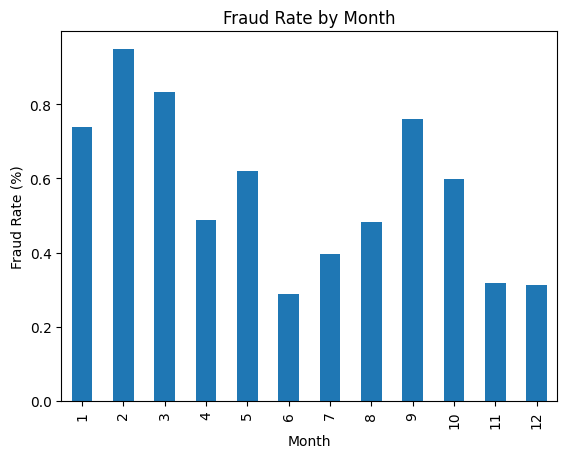

In [89]:
fraud_rate_month = (
    df.groupby("month")["is_fraud"]
    .mean()
    .mul(100)
)

fraud_rate_month.plot(
    kind="bar",
    title="Fraud Rate by Month",
    ylabel="Fraud Rate (%)",
    xlabel="Month"
)

<Axes: title={'center': 'Fraud Rate by Month'}, xlabel='Month', ylabel='Fraud Rate (%)'>

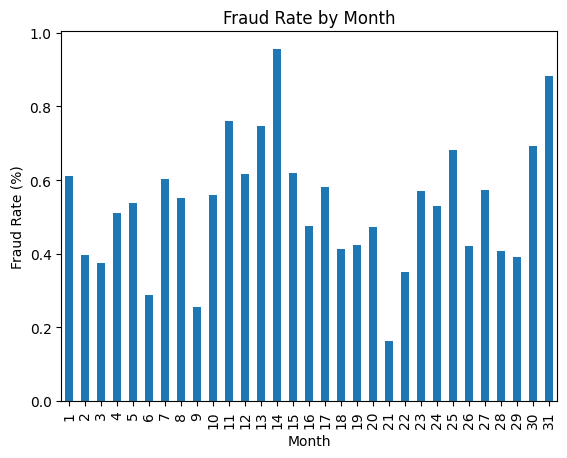

In [90]:
fraud_rate_month = (
    df.groupby("day")["is_fraud"]
    .mean()
    .mul(100)
)

fraud_rate_month.plot(
    kind="bar",
    title="Fraud Rate by Month",
    ylabel="Fraud Rate (%)",
    xlabel="Month"
)

<Axes: title={'center': 'Fraud Rate by Month'}, xlabel='Month', ylabel='Fraud Rate (%)'>

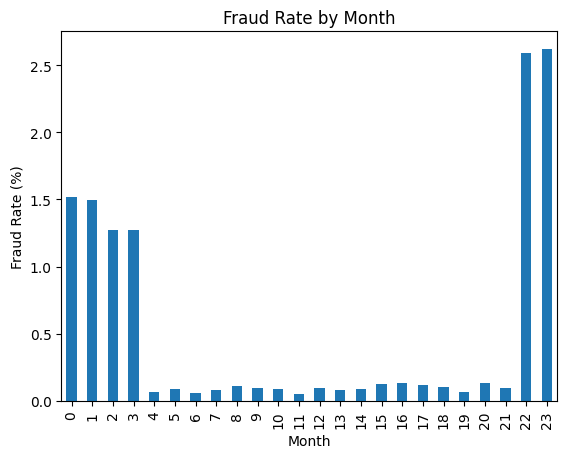

In [91]:
fraud_rate_month = (
    df.groupby("hour")["is_fraud"]
    .mean()
    .mul(100)
)

fraud_rate_month.plot(
    kind="bar",
    title="Fraud Rate by Month",
    ylabel="Fraud Rate (%)",
    xlabel="Month"
)

In [92]:
def is_night_transaction(hour):
    if 0 <= hour <= 3:
      return 1
    if 22<= hour <= 24:
      return 2
    return 0
df["night_transaction"] = df["hour"].apply(is_night_transaction)

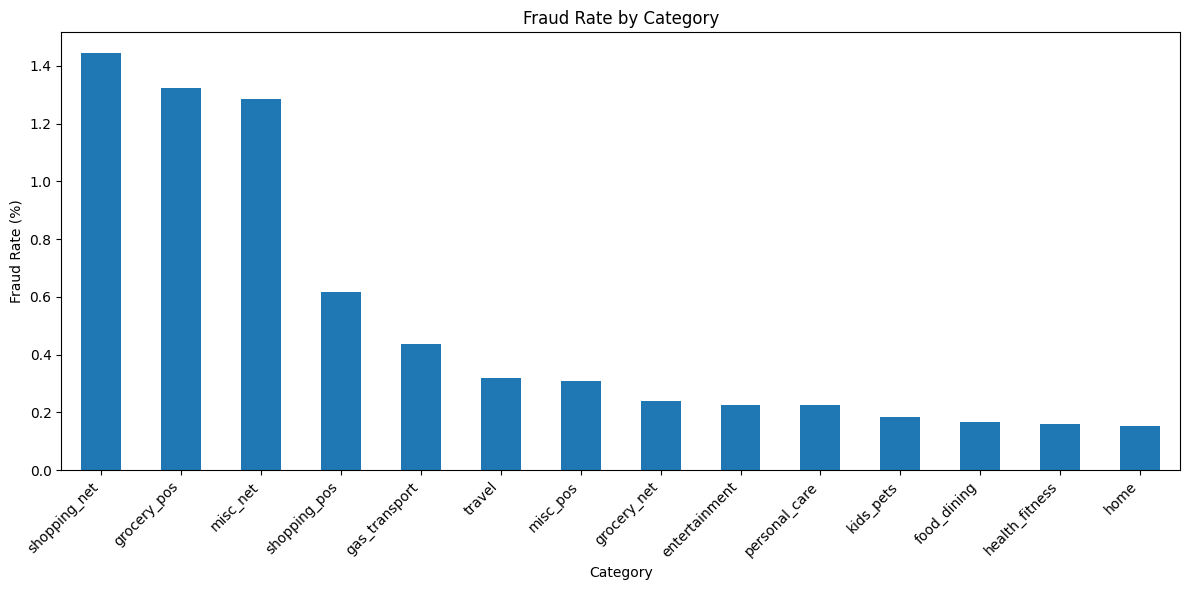

In [93]:
category_fraud_rate = (
    df.groupby("category")["is_fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
category_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

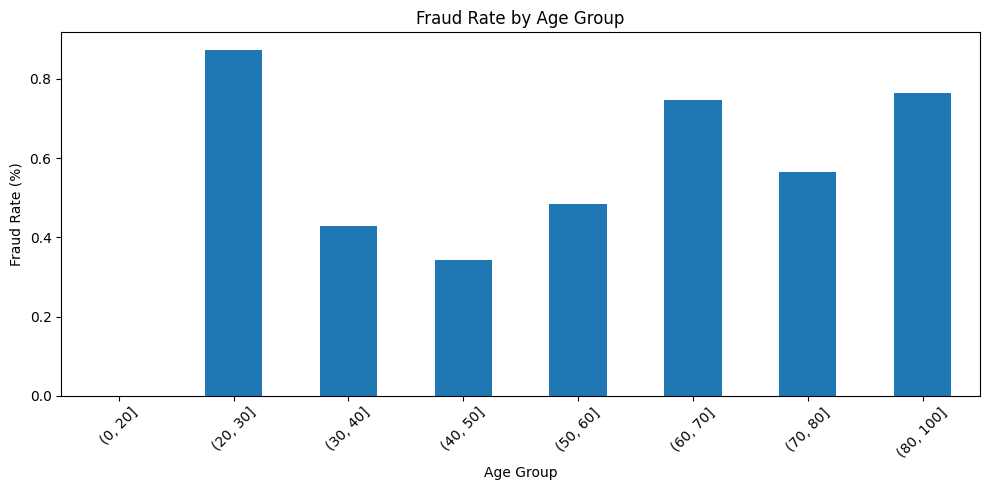

In [94]:
age_bins = [0, 20, 30, 40, 50, 60, 70, 80, 100]

fraud_rate_age = (
    df.groupby(
        pd.cut(df["age"], bins=age_bins),
        observed=False
    )["is_fraud"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 5))
fraud_rate_age.plot(kind="bar")
plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
fraud_count_by_age = (
    df[df["is_fraud"] == 1]
    .groupby("age")
    .size()
    .sort_values(ascending=True)
)

print(fraud_count_by_age.head(10))

age
78     6
83     6
99     6
68     7
64     8
80     8
55     8
49     9
26    10
88    11
dtype: int64


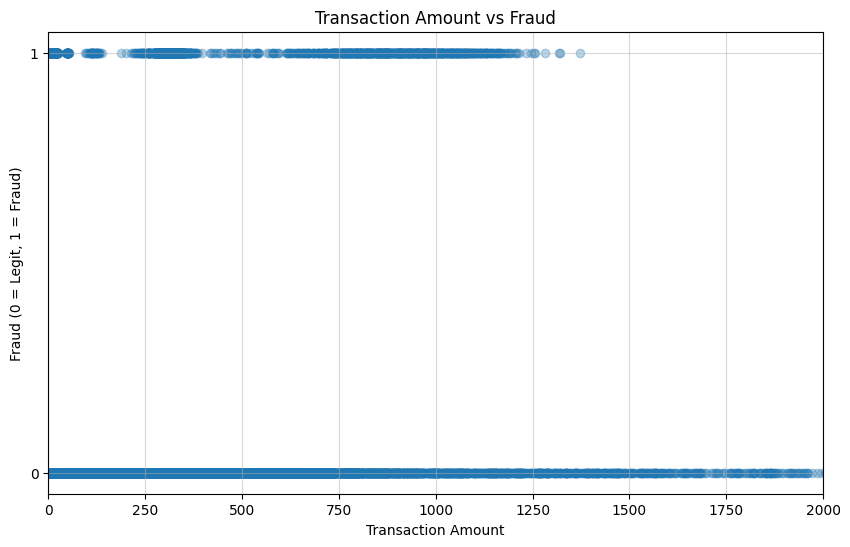

In [96]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["amt"],
    df["is_fraud"],
    alpha=0.3
)

plt.xlabel("Transaction Amount")
plt.ylabel("Fraud (0 = Legit, 1 = Fraud)")
plt.title("Transaction Amount vs Fraud")

plt.xlim(0, 2000)
plt.yticks([0, 1])
plt.grid(True, alpha=0.5)

plt.show()

In [97]:
df["high_amt"] = (df["amt"] > 1500).astype(int)

In [98]:
(
    df[df["is_fraud"] == 1]
    .groupby("job")
    .size()
    .sort_values(ascending=False)
)

,0
job,
Colour technologist,29
Systems analyst,28
"Surveyor, minerals",25
Naval architect,24
Network engineer,24
...,...
Clinical research associate,3
Teaching laboratory technician,3
Health physicist,3


In [99]:
(
    df[df["is_fraud"] == 1]
    .groupby("city")
    .size()
    .sort_values(ascending=False)
)

,0
city,
Albuquerque,24
Aurora,23
Fort Washakie,21
Glendale,20
Mesa,20
...,...
Newhall,3
Odessa,3
Vancouver,3


In [100]:
from sklearn.preprocessing import LabelEncoder

In [101]:
le = LabelEncoder()

categorical_cols = ['merchant', 'category', 'city', 'state', 'job']

In [103]:
y = df['is_fraud']
X = df.drop('is_fraud', axis=1)

In [106]:
df.to_csv('processed_credit_card_frauds.csv', index=False)